# Task 1 — GPT-style character-level LLM from scratch on TinyStories
**DATA266 Lab 1 · Member: Shibin Thomas**

This notebook is the walkthrough of my Task 1 work. The real logic lives in the tested modules
next to it in `src/` (`data_prep.py`, `model.py`, `train.py`, `evaluate.py`, `analyze_failures.py`);
the notebook calls them, so the notebook and the one-command CLI give identical results.

| Brief section | Where |
|---|---|
| 1.1 Data preprocessing (char tokenisation, fixed-length sequences, `char_to_idx`/`idx_to_char`, own 100K/10K split) | §1 below, `src/data_prep.py` |
| 1.2 GPT implementation (MHSA, LayerNorm, FFN, residuals, causal mask, token + positional embeddings, LM head) | §2, `src/model.py` |
| 1.3 Training (cross-entropy, warm-up + cosine schedule, ≥10 epochs, loss curves, greedy/temperature generation) | §3–4, `src/train.py`, `src/evaluate.py` |
| 1.4 Failure analysis (3 cases) | §5, `failure_analysis.md` |
| All Task 1 metrics | §4, `metrics_report.csv` |

**No prebuilt Transformer or attention modules are used** (no `nn.MultiheadAttention`, `nn.Transformer*`,
`nn.LayerNorm`, `F.scaled_dot_product_attention`) — enforced by `tests/test_model.py`.

> For the long 10-epoch GPU run, the CLI is recommended (it survives notebook disconnects and can resume):
> `python task1_llm/shibin_thomas/src/run_pipeline.py --config task1_llm/shibin_thomas/configs/gpt_char_v1.yaml`
> then execute this notebook: with `RUN_TRAINING = "auto"` it re-uses that finished run instead of training again.

In [1]:
# ---- Settings -------------------------------------------------------------------------------
CONFIG = "task1_llm/shibin_thomas/configs/gpt_char_v1.yaml"   # smoke test: configs/smoke.yaml
OVERRIDES = []           # e.g. ["training.batch_size=32"]
RUN_TRAINING = "auto"    # "auto": train only if no finished run of this config exists; True / False to force
RUN_ID = "latest"        # run to analyse when not training: a run id under checkpoints/, or "latest"

In [2]:
import sys, json, math
from pathlib import Path

# locate the repo root from wherever the notebook is opened (no hard-coded personal paths)
here = Path.cwd().resolve()
REPO = next((p for p in [here, *here.parents] if (p / "task1_llm").is_dir()), None)
assert REPO is not None, "open this notebook from inside the cloned repository"
SRC = REPO / "task1_llm" / "shibin_thomas" / "src"
sys.path.insert(0, str(SRC))

import numpy as np, torch, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

from utils import load_config, repo_path, read_json, get_device, run_dirs, latest_run_id, rel
from data_prep import prepare_data, load_vocab, encode, decode, CharStream, EOS_ID
from model import GPTCharLM, GPTConfig
cfg = load_config(CONFIG, OVERRIDES)
device = get_device(cfg.get("device", "auto"))
print("repo:", REPO.name, "| config:", cfg["_config_path"], "| device:", device, "| torch", torch.__version__)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

repo: Gen-AI---LAB-1 | config: task1_llm/shibin_thomas/configs/gpt_char_v1.yaml | device: cuda | torch 2.11.0+cu128
GPU: NVIDIA GeForce RTX 5090


## 1. Data preprocessing (1.1)
1. **Load + clean** the shared raw TinyStories file. Typographic unicode (’ “ ” — …) is mapped to ASCII,
   whitespace is normalised, and stories that still contain non-ASCII characters or are shorter than
   50 characters are dropped (counts are logged). This keeps the character vocabulary small (~95)
   and avoids wasting capacity on rare mojibake symbols.
2. **My own split**: from the clean pool I sample, with my own seed (`split_seed: 266`), **100,000 training
   and 10,000 validation stories** (disjoint). The raw-line indices are saved in `split_indices.npz`.
3. **Character vocabulary** `char_to_idx` / `idx_to_char` is built from the *training* split only.
   Two special ids: `0 = <eos>` (end of story — lets the model learn where stories end) and
   `1 = <unk>` (validation character never seen in training).
4. Every story is encoded, followed by `<eos>`, and concatenated into one integer stream per split (`uint8`).
5. **Fixed-length input–target sequences**: windows of `block_size = 256` characters,
   `x = s[i : i+256]`, `y = s[i+1 : i+257]` (target = input shifted by one character).

In [3]:
processed = prepare_data(cfg)
meta = read_json(processed / "meta.json")
char_to_idx, idx_to_char = load_vocab(processed)
print(json.dumps({k: meta[k] for k in ["raw_status_counts", "vocab_size", "train", "val",
                                       "sequences_per_epoch_estimate", "optimizer_steps_per_epoch_estimate"]}, indent=1))

[data] reusing processed data in task1_llm/shibin_thomas/data_processed/main (same data config)
{
 "raw_status_counts": {
  "ok": 1989367,
  "non_ascii": 130115,
  "too_short": 237
 },
 "vocab_size": 90,
 "train": {
  "stories": 100000,
  "tokens": 90162497,
  "unk_tokens": 0,
  "story_chars_mean": 900.62497,
  "story_chars_median": 783.0,
  "story_chars_p95": 1787.0,
  "story_chars_max": 4349
 },
 "val": {
  "stories": 10000,
  "tokens": 8956317,
  "unk_tokens": 0,
  "story_chars_mean": 894.6317,
  "story_chars_median": 781.0
 },
 "sequences_per_epoch_estimate": 352197,
 "optimizer_steps_per_epoch_estimate": 5503
}


train stories=100,000  val stories=10,000  overlap=0


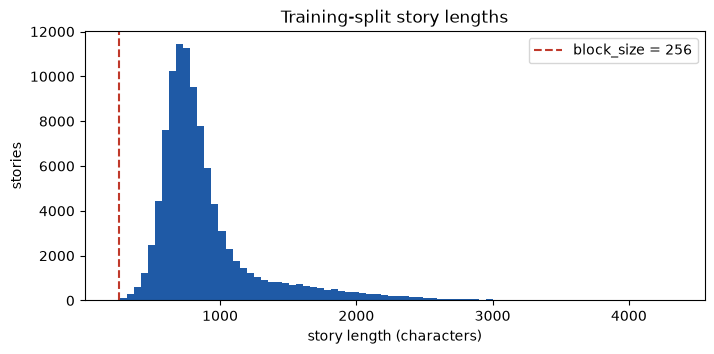

mean=901  median=783  p95=1787 chars


In [4]:
# own split: sizes + disjointness check
split = np.load(processed / "split_indices.npz")
tr, va = split["train_lines"], split["val_lines"]
print(f"train stories={len(tr):,}  val stories={len(va):,}  overlap={len(np.intersect1d(tr, va))}")

# story length distribution (characters) of my training split, decoded back from the stream
train_ids = np.fromfile(processed / "train.bin", dtype=np.uint8)
eos_pos = np.flatnonzero(train_ids == EOS_ID)
lengths = np.diff(np.concatenate([[-1], eos_pos])) - 1
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(lengths, bins=80, color="#1f5aa6")
ax.axvline(cfg["model"]["block_size"], color="#c0392b", ls="--", label=f"block_size = {cfg['model']['block_size']}")
ax.set(xlabel="story length (characters)", ylabel="stories", title="Training-split story lengths"); ax.legend()
plt.show()
print(f"mean={lengths.mean():.0f}  median={np.median(lengths):.0f}  p95={np.percentile(lengths, 95):.0f} chars")

In [5]:
# the char_to_idx / idx_to_char dictionaries
print("vocab size:", len(char_to_idx))
print("char_to_idx:", {repr(c): i for c, i in list(char_to_idx.items())})
print("idx_to_char[0..5]:", {i: idx_to_char[i] for i in range(6)})

text = "Once upon a time, Lily saw a cat."
ids = encode(text, char_to_idx)
print("\nencode:", ids)
print("decode:", decode(ids, idx_to_char))
assert decode(ids, idx_to_char) == text

vocab size: 90
char_to_idx: {"'<eos>'": 0, "'<unk>'": 1, "'\\n'": 2, "' '": 3, "'!'": 4, '\'"\'': 5, "'$'": 6, "'&'": 7, '"\'"': 8, "'('": 9, "')'": 10, "'*'": 11, "'+'": 12, "','": 13, "'-'": 14, "'.'": 15, "'/'": 16, "'0'": 17, "'1'": 18, "'2'": 19, "'3'": 20, "'4'": 21, "'5'": 22, "'6'": 23, "'7'": 24, "'8'": 25, "'9'": 26, "':'": 27, "';'": 28, "'='": 29, "'?'": 30, "'A'": 31, "'B'": 32, "'C'": 33, "'D'": 34, "'E'": 35, "'F'": 36, "'G'": 37, "'H'": 38, "'I'": 39, "'J'": 40, "'K'": 41, "'L'": 42, "'M'": 43, "'N'": 44, "'O'": 45, "'P'": 46, "'Q'": 47, "'R'": 48, "'S'": 49, "'T'": 50, "'U'": 51, "'V'": 52, "'W'": 53, "'X'": 54, "'Y'": 55, "'Z'": 56, "'['": 57, "'\\\\'": 58, "']'": 59, "'_'": 60, "'`'": 61, "'a'": 62, "'b'": 63, "'c'": 64, "'d'": 65, "'e'": 66, "'f'": 67, "'g'": 68, "'h'": 69, "'i'": 70, "'j'": 71, "'k'": 72, "'l'": 73, "'m'": 74, "'n'": 75, "'o'": 76, "'p'": 77, "'q'": 78, "'r'": 79, "'s'": 80, "'t'": 81, "'u'": 82, "'v'": 83, "'w'": 84, "'x'": 85, "'y'": 86, "'z'": 8

In [6]:
# fixed-length (input, target) pairs exactly as the training loop sees them
T = cfg["model"]["block_size"]
stream = CharStream(processed / "train.bin", T, torch.device("cpu"))
x, y = next(stream.batches(stream.eval_starts(4), batch_size=4))
print("x shape", tuple(x.shape), "| y shape", tuple(y.shape))
print("x[0][:12] =", x[0, :12].tolist())
print("y[0][:12] =", y[0, :12].tolist(), "  (shifted by one)")
print("\nx text:", repr(decode(x[0, :80].tolist(), idx_to_char)))
print("y text:", repr(decode(y[0, :80].tolist(), idx_to_char)))
assert torch.equal(x[0, 1:], y[0, :-1])

x shape (4, 256) | y shape (4, 256)
x[0][:12] = [75, 68, 15, 3, 38, 66, 3, 68, 70, 83, 66, 80]
y[0][:12] = [68, 15, 3, 38, 66, 3, 68, 70, 83, 66, 80, 3]   (shifted by one)

x text: 'ng. He gives the ashtray and the coins to Mom. He hugs Ben and says he is sorry.'
y text: 'g. He gives the ashtray and the coins to Mom. He hugs Ben and says he is sorry.\n'


## 2. GPT model implemented from scratch (1.2)
Pre-LayerNorm GPT (GPT-2 layout), all components hand-written in `src/model.py`:

* `LayerNorm` — mean/variance normalisation with learnable γ, β (computed in fp32 for mixed-precision stability)
* `CausalSelfAttention` — fused Q/K/V projection, split into heads, `softmax(QKᵀ/√d_k + mask)·V`,
  heads concatenated, output projection; **causal mask** = lower-triangular boolean buffer, future
  positions are set to −∞ before the softmax
* `FeedForward` — Linear(d, 4d) → GELU → Linear(4d, d) → dropout
* `TransformerBlock` — `x = x + MHSA(LN(x)); x = x + FFN(LN(x))` (residual connections)
* learnable **token embedding** (`vocab × d`) + learnable **positional embedding** (`block_size × d`)
* final LayerNorm + **LM head** `Linear(d → vocab)` producing next-character logits (weight-tied to the token embedding)

In [7]:
gcfg = GPTConfig(vocab_size=meta["vocab_size"], **cfg["model"])
model = GPTCharLM(gcfg)
print(model)
print(f"\nparameters: {model.num_params():,} total | {model.num_params(non_embedding=True):,} non-embedding")

GPTCharLM(
  (tok_emb): Embedding(90, 320)
  (pos_emb): Embedding(256, 320)
  (drop): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-5): 6 x TransformerBlock(
      (ln1): LayerNorm()
      (attn): CausalSelfAttention(
        (qkv): Linear(in_features=320, out_features=960, bias=True)
        (proj): Linear(in_features=320, out_features=320, bias=True)
        (attn_drop): Dropout(p=0.1, inplace=False)
        (resid_drop): Dropout(p=0.1, inplace=False)
      )
      (ln2): LayerNorm()
      (ffn): FeedForward(
        (fc1): Linear(in_features=320, out_features=1280, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=1280, out_features=320, bias=True)
        (drop): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (ln_f): LayerNorm()
  (lm_head): Linear(in_features=320, out_features=90, bias=False)
)

parameters: 7,509,120 total | 7,398,400 non-embedding


In [8]:
# Causal-masking check: perturbing characters at positions >= cut must not change logits before cut.
model.eval()
cut = T // 2
xx = x[:1, :T].clone()
xx2 = xx.clone(); xx2[0, cut:] = (xx2[0, cut:] + 5) % meta["vocab_size"]
with torch.no_grad():
    l1, _ = model(xx); l2, _ = model(xx2)
print(f"max |Δlogits| at positions <  {cut}:", (l1[0, :cut] - l2[0, :cut]).abs().max().item(), "(must be 0)")
print(f"max |Δlogits| at positions >= {cut}:", (l1[0, cut:] - l2[0, cut:]).abs().max().item())
print("initial loss (should be ≈ ln V =", round(math.log(meta['vocab_size']), 3), "):",
      round(model(x[:, :T], y[:, :T])[1].item(), 3))

max |Δlogits| at positions <  128: 0.0 (must be 0)
max |Δlogits| at positions >= 128: 1.7227017879486084
initial loss (should be ≈ ln V = 4.5 ): 4.631


## 3. Training (1.3)
* **Loss**: cross-entropy over next-character predictions (mean over all positions).
* **Optimiser**: AdamW (β = 0.9/0.95, weight decay 0.1 on matrices/embeddings only), gradient clipping at 1.0.
* **LR schedule**: linear **warm-up** over the first 2 % of steps to 6e-4, then **cosine decay** to 6e-5.
* **10 epochs**; one epoch = every training character is a target once (non-overlapping 256-char windows,
  random offset + shuffle each epoch).
* Mixed precision (bf16/fp16) on GPU; after each epoch: full validation pass, eval-mode train loss,
  checkpointing (best + resumable last), and a greedy sample in the raw log.
* Raw, append-only logs: `reproducibility/raw_logs/task1_llm/shibin_thomas/<run_id>/`.

In [9]:
from train import train
from utils import MEMBER_DIR
finished = sorted((p.parent.name for p in (MEMBER_DIR / "outputs").glob(f"{cfg['run_name']}_*/train_summary.json")))
if RUN_TRAINING == "auto":
    RUN_TRAINING = not finished
if RUN_TRAINING:
    RUN_ID = train(cfg)
elif RUN_ID == "latest":
    RUN_ID = finished[-1]          # newest finished run (run ids end in a sortable timestamp)
print("trained now" if RUN_TRAINING else "re-using finished run")
dirs = run_dirs(RUN_ID)
print("run:", RUN_ID)
epochs_df = pd.read_csv(dirs["raw_logs"] / "epochs.csv")
epochs_df

re-using finished run
run: gpt_char_v1_20261001-153007


,epoch,step,lr,train_loss_running,train_loss_eval,val_loss,val_ppl,val_bpc,val_top1_acc,train_top1_acc,gen_gap,epoch_time_sec,tokens_per_sec
0,1,5503,0.000591,1.05056,0.71287,0.71534,2.0449,1.0320,0.77356,0.77414,0.00248,169.6,531728.3
1,2,11006,0.000556,0.72155,0.66208,0.66612,1.9467,0.9610,0.78838,0.78935,0.00405,178.9,504078.1
2,3,16509,0.000498,0.68438,0.63571,0.64196,1.9002,0.9262,0.79574,0.79716,0.00625,176.2,511708.7
3,4,22012,0.000423,0.66250,0.61879,0.62542,1.8690,0.9023,0.80072,0.80230,0.00664,175.4,514136.5
4,5,27515,0.000339,0.64558,0.60498,0.61210,1.8443,0.8831,0.80478,0.80644,0.00712,170.6,528530.9
5,6,33018,0.000253,0.63105,0.59162,0.60001,1.8221,0.8656,0.80831,0.81023,0.00840,169.5,531774.6
6,7,38521,0.000176,0.61886,0.58034,0.58959,1.8033,0.8506,0.81156,0.81367,0.00926,169.3,532650.0
7,8,44024,0.000114,0.60712,0.57074,0.58086,1.7876,0.8380,0.81436,0.81675,0.01012,169.7,531152.6
8,9,49527,0.000074,0.59819,0.56325,0.57391,1.7752,0.8280,0.81631,0.81880,0.01067,169.4,532318.2
9,10,55030,0.000060,0.59184,0.55966,0.57105,1.7701,0.8239,0.81726,0.82009,0.01140,177.7,507371.1


## 4. Evaluation — loss curves, generation, all Task 1 metrics
`evaluate.py` re-loads the **best** checkpoint (lowest validation loss) and computes every metric in the brief,
using the team's shared metric definitions in `task1_llm/shared_eval/metrics.py` and the shared prompts in
`task1_llm/shared_eval/prompts.json`. Generation uses **greedy decoding** and **temperature sampling (T = 0.8)**.

In [10]:
from evaluate import evaluate
metrics = evaluate(cfg, RUN_ID)
report = pd.read_csv(dirs["outputs"] / "metrics_report.csv")
report

2026-10-01 16:38:38 | INFO | EVAL run gpt_char_v1_20261001-153007 best_model epoch=10 step=55030 device=cuda


2026-10-01 16:39:36 | INFO | val_loss=0.5711 val_acc=0.8173 train_loss=0.5594 train_acc=0.8202


2026-10-01 16:40:44 | INFO | metrics: train_cross_entropy=0.5594, val_cross_entropy=0.5711, val_perplexity=1.7701, val_bits_per_char=0.8239, train_perplexity=1.7497, train_bits_per_char=0.8071, generalization_gap=0.0116, val_top1_accuracy=0.8173, train_top1_accuracy=0.8202, train_loss_running_last_epoch=0.5918, distinct_1=0.2277, distinct_2=0.7048, distinct_3=0.9264, repeated_4gram_rate=0.0066, greedy_distinct_1=0.2008, greedy_distinct_2=0.5392, greedy_distinct_3=0.7191, greedy_repeated_4gram_rate=0.1373, generation_tokens_per_sec=254.9890, grad_norm_mean=0.3039, grad_norm_p99=1.1454, grad_norm_max=14.7102, frac_steps_clipped=0.0134, loss_spikes=0, nonfinite_steps=0, params_total=7,509,120, params_non_embedding=7,398,400, train_tokens_per_sec=569,917, total_training_time_sec=1735.7491, epochs=10, best_epoch=10, total_training_time_min=28.9292, peak_cpu_rss_mb=2366.6172, peak_gpu_allocated_mb=3346.5425, peak_gpu_reserved_mb=4166.0000, hardware=NVIDIA GeForce RTX 5090, run_id=gpt_char_v1

2026-10-01 16:40:44 | INFO | promoted metrics_report.csv to member folder and refreshed results.md table


2026-10-01 16:40:44 | INFO | EVAL DONE -> task1_llm/shibin_thomas/outputs/gpt_char_v1_20261001-153007


,metric,value,notes
0,Training cross-entropy loss,0.5594495136774372,"nats/char, eval mode, best ckpt"
1,"Training loss (running avg, last epoch)",0.59184,"nats/char, with dropout"
2,Validation cross-entropy loss,0.5710512466288915,"nats/char, best ckpt"
3,Perplexity (validation),1.770126913626184,"exp(val CE), per char"
4,Bits-per-character (validation),0.8238528016049622,val CE / ln 2
5,Perplexity (train),1.7497090442384224,exp(train CE)
6,Bits-per-character (train),0.807115039010181,train CE / ln 2
7,Generalization gap,0.01160173295145428,val CE - train CE (nats)
8,Top-1 next-character accuracy (validation),0.8172604107117336,fraction
9,Top-1 next-character accuracy (train),0.8201836325799198,fraction


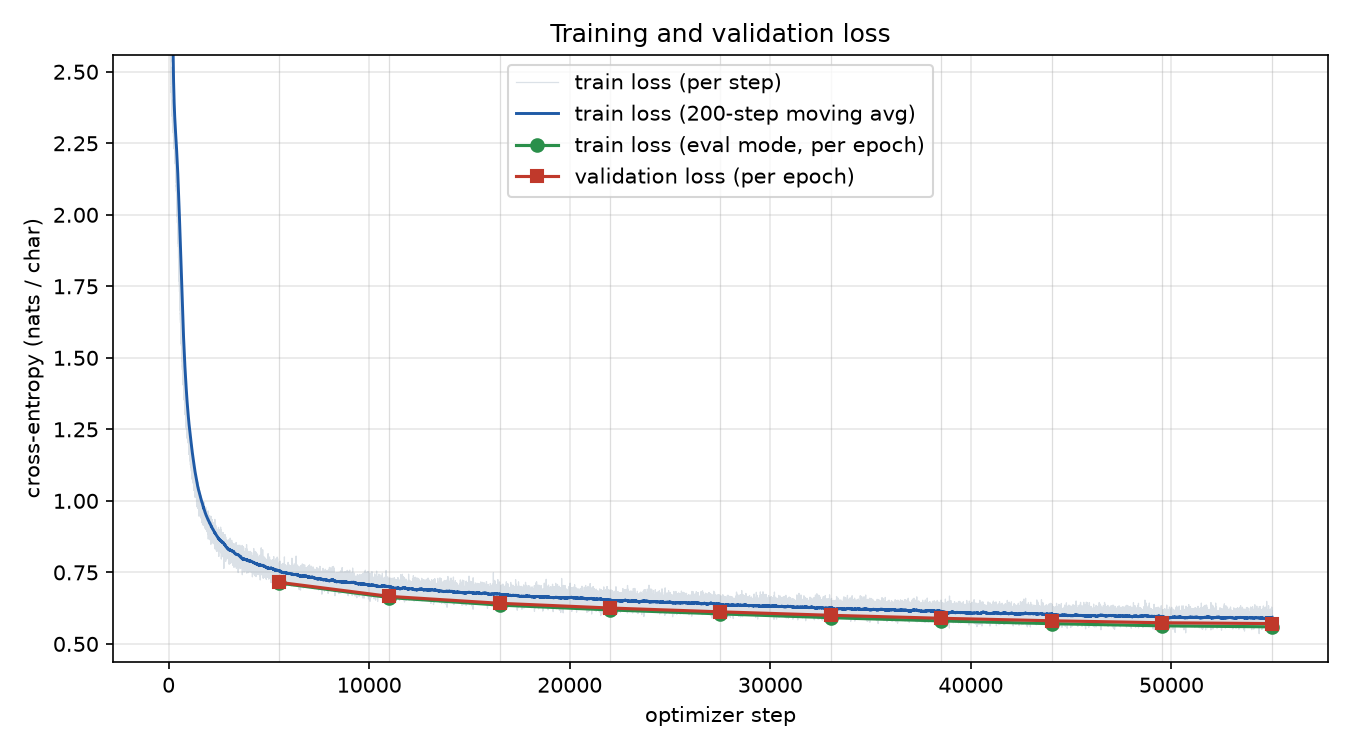

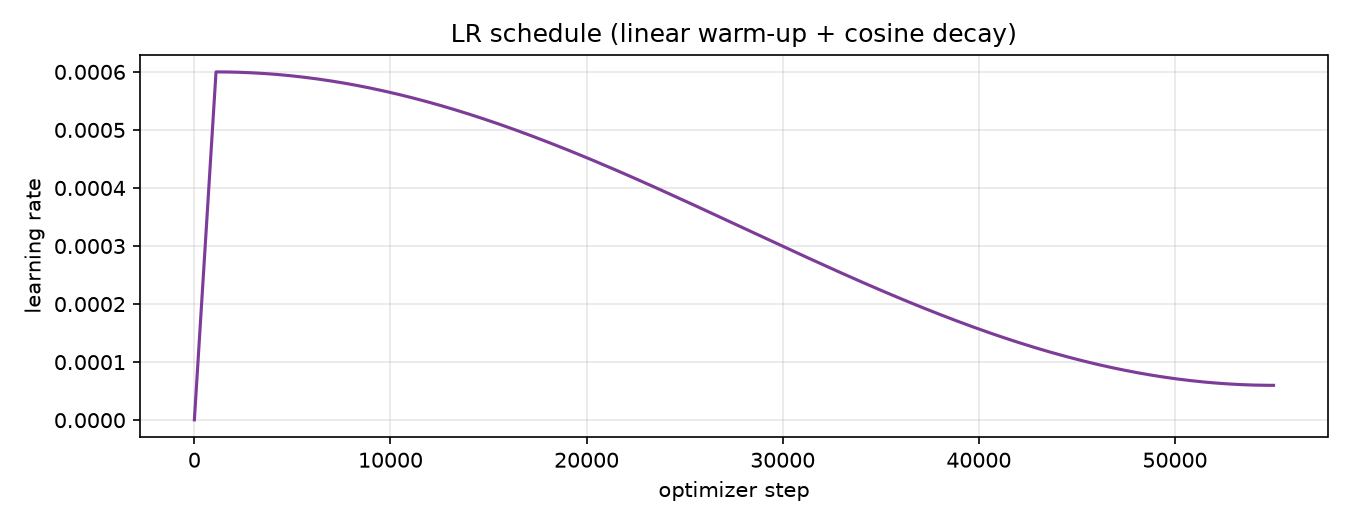

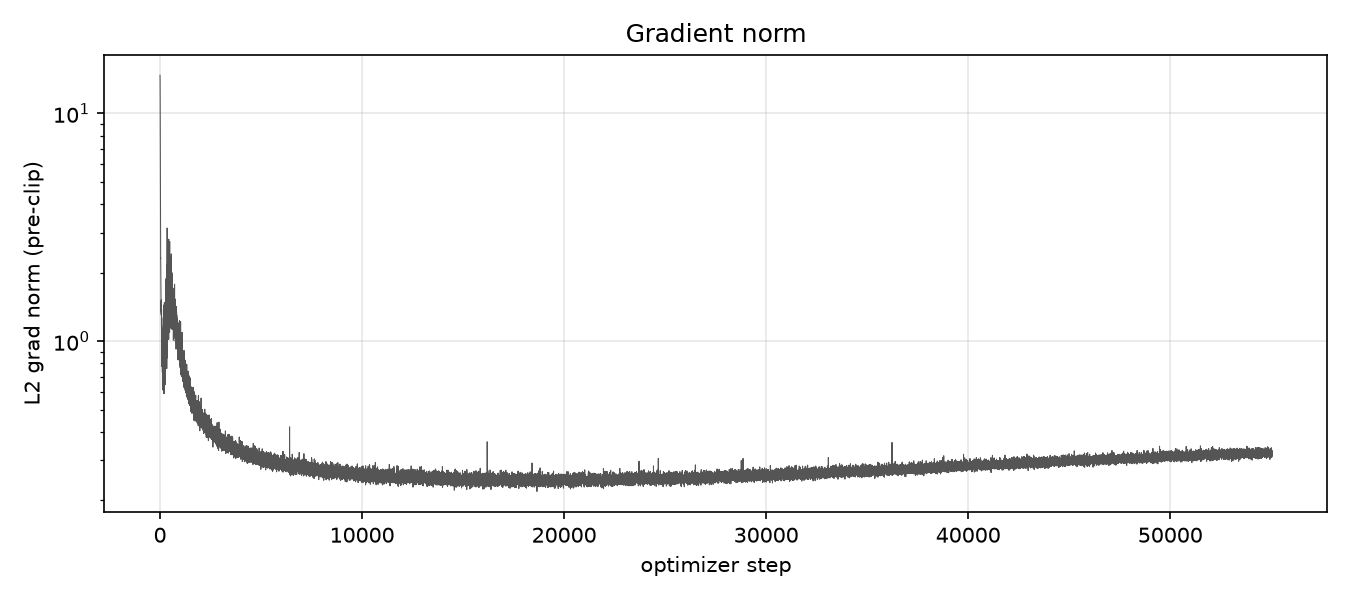

In [11]:
display(Image(filename=str(dirs["outputs"] / "loss_curves.png")))
display(Image(filename=str(dirs["outputs"] / "lr_schedule.png")))
display(Image(filename=str(dirs["outputs"] / "grad_norm.png")))

In [12]:
samples = read_json(dirs["outputs"] / "samples.json")
for s in samples[:8]:
    tag = s["mode"] + ("" if s["sample_idx"] is None else f" #{s['sample_idx']}")
    display(Markdown(f"**{s['prompt']}** _({tag})_ → {s['continuation'][:400]}" + (" `[EOS]`" if s["ended_with_eos"] else "")))

**Once upon a time** _(greedy)_ → , there was a little girl named Lily. She loved to play outside in the sunshine. One day, she saw a big bug on the ground. She wanted to pick it up and put it in the sunshine.

Lily went to the bug and said, "Hello, bug! What is that?" The bug didn't know what to do. Lily was sad because she couldn't pick it up.

But then, Lily's mom came in and said, "Lily, you can't pick the bug anymore. It's to

**Once upon a time** _(temp0.8 #0)_ → , there was a girl named Lily. She had a big, brown dog named Max. Max was very friendly and loved to play with Lily. One day, Lily was playing in her room when she heard a loud noise. Max looked out the window and saw a butterfly in the sky. Lily stopped to watch her butterfly follow her. Max realized that the butterfly wasn't as easy as a real.

Lily was happy to hear that Max was lying on the t

**Once upon a time** _(temp0.8 #1)_ → , there was a fisherman named Percil. Percil was an only fish, but he was very powerful. He had found a special shine in the sea in the sea.

Percy knew that he had not known an idea. He went to the sea and catched it with its feathers. He took it on the shore and then he saw the big ship on the way. The ship opened up and the ship was filled with the mountain. Perhaps came and the ship was beauti

**Once upon a time** _(temp0.8 #2)_ → , there was a little girl named Lily. She loved to play in her room with her dolls. One day, she found a big basket of candy and she thought it looked so yummy.

Lily's mom said, "Wow, that's a good choice. Let's drink some tasty candy!" Lily smiled and nodded at Lily's hand. They walked to the basket and got all wet. Lily felt proud of herself for doing the right thing and decided to wash the can

**One day, a little girl named Lily** _(greedy)_ →  went to the park with her mommy. They saw a big slide and wanted to go on it. Lily was sad because she wanted to go to the slide too.

As they were walking, Lily saw a big boy who wanted to play with him. She asked him if he wanted to play with her toys. The boy said yes, but he was stubborn and didn't want to share.

Lily was sad and started to cry. She wanted to play with him, but her mom said 

**One day, a little girl named Lily** _(temp0.8 #0)_ →  went to the park to play with her friends. The park was funny and she saw a big puddle of water. She decided to take the puddle home and splash into it.

When she got to the puddle, she saw lots of plumbers. But when she did this exam, the puddle splashed around her waist. The plumber splashed around in the puddles, and the water splashing in the water. Lily was scared, but she knew she had to ge

**One day, a little girl named Lily** _(temp0.8 #1)_ →  went to the park with her mommy. They saw a big bush near a tree and felt curious. Lily really wanted to pick it up and really tasty.

"Mommy, can I have a bush too?" she asked.

Mommy nodded and said, "Yes, but we have to go inside. Mommy will be in the witch and then we can go in another seat."

Lily bravely was curious and waited for the bush. She hopped in the wildffice and set off to the wes

**One day, a little girl named Lily** _(temp0.8 #2)_ →  found a new toy. It was a big, shiny ornament with stars. It was a long tail. Lily was very curious and wanted to know what it could do.

Her mom saw the toy and asked, "What is that, Lily?"

"That is a difficult idea," her mom replied.

"I don't know," Lily said.

"It's not fun," her mom said. "Let's keep an eye on the big tree."

They curled up and examined the tree. Lily was so happy that her  `[EOS]`

In [13]:
# attention pattern of the trained model (block 1, head 1) on a validation snippet -- lower-triangular by construction
from evaluate import load_model
best, _ = load_model(dirs["checkpoints"] / "best_model.pt", torch.device("cpu"))
snippet = "Once upon a time, there was a little girl named Lily. She loved to play."
ids = torch.tensor([encode(snippet, char_to_idx)[:best.cfg.block_size]])
best.blocks[0].attn.store_attn = True
with torch.no_grad():
    best(ids)
A = best.blocks[0].attn.last_attn[0, 0].numpy()
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(A, cmap="viridis"); ax.set(title="Block 1 / head 1 attention", xlabel="key position", ylabel="query position")
plt.show()

C:\Users\shibin\AppData\Local\Temp\ipykernel_68288\6824674.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 5. Failure analysis (1.4)
`analyze_failures.py` ranks the generated samples by repetition, out-of-vocabulary (invented/broken) words,
coherence signals (character-name drift, never ending the story) and grammar signals. I read the
candidates and wrote up three real failure cases — snippet, failure type and observation — in
[`failure_analysis.md`](../failure_analysis.md).

In [14]:
import subprocess
subprocess.run([sys.executable, str(SRC / "analyze_failures.py"), "--config", CONFIG, "--run-id", RUN_ID,
                "--set", *OVERRIDES], check=True)
display(Markdown((dirs["outputs"] / "failure_candidates.md").read_text(encoding="utf-8")[:6000]))

# Failure candidates - gpt_char_v1_20261001-153007

Automatically ranked from `samples.json`. Read them, pick three genuine failures, and write them up in `failure_analysis.md`.

## Repetition (highest repeated-4-gram rate)

- **'In a small house near the forest,' / greedy** - rep4=0.61, repeats=[('the tree was very', 16), ('tree was very high', 13), ('and the tree was', 7)], OOV=[], names=[], no_eos=True, doubled=[], unbalanced_quotes=False

  ```text
  In a small house near the forest, there was a big tree. The tree was very high and the tree was very high. The tree was very high up in the tree. The tree was very high and the tree was very high.
  
  One day, the tree saw a big tree. The tree was very high and the tree was very high. The tree was very high and the tree was very high. The tree was very high and the tree was very high. The tree was very high and the tree was very high.
  
  The tree was very happy to see the tree and the tree was very happy. The tree was very proud of 
  ```

- **'There was a big red ball' / greedy** - rep4=0.34, repeats=[('the ball was sad', 5), ('ball was sad and', 5), ('wanted to play with', 5)], OOV=[], names=[], no_eos=True, doubled=[], unbalanced_quotes=False

  ```text
  There was a big red ball in the park. It was so big and shiny and had a long tail. The ball was so happy to see it.
  
  But then, a big wind came and the ball went away. The ball was sad and didn't know what to do. The ball was sad and wanted to play with it. The ball wanted to play with the ball and the ball. The ball was sad and wanted to play with the ball.
  
  The ball was sad and didn't know what to do. The ball was sad and wanted to help the ball. The ball wanted to play with the ball too. The ball wanted to play with 
  ```

- **'The sun was shining and' / greedy** - rep4=0.16, repeats=[('the bird was so', 2), ('bird was so happy', 2), ('the bird said thank', 2)], OOV=['togethe'], names=['Thank'], no_eos=True, doubled=[], unbalanced_quotes=False

  ```text
  The sun was shining and the sky was blue. The bird was so happy to see the sun shine brightly in the sky. The sun was shining and the bird was so happy.
  
  The bird said, "Thank you for helping me find my way home. I will fly again soon."
  
  The bird smiled and said, "You're welcome, bird. I'm glad you are so kind."
  
  The bird said, "Thank you for helping me find my way home."
  
  The bird said, "You're welcome, bird. I'm glad you like it. Now let's go home and play with your friends."
  
  The bird and the bird went home togethe
  ```

- **'The cat saw a bird and' / greedy** - rep4=0.13, repeats=[('the bird said you', 3), ('bird said you are', 3), ('want to play with', 2)], OOV=[], names=['Hello', 'Thank'], no_eos=True, doubled=[], unbalanced_quotes=True

  ```text
  The cat saw a bird and said, "Hello, bird. Do you want to play with me?" The bird said, "Yes, I want to play with you." The bird said, "You are so cute and fluffy. I will play with you." The bird said, "Thank you, bird. You are very nice." The bird said, "You are welcome, but you are also very kind." The bird said, "You are very kind and smart. I love you too." The bird said, "I love you too, but you have to be careful. I will be careful and stay with me." The bird said, "I will be careful not to be careless and stay
  ```

## Broken / invented words (most out-of-vocabulary words)

- **'In a small house near the forest,' / temp0.8 #2** - rep4=0.00, repeats=[], OOV=['lute', 'luter', 'lutte', 'lutter'], names=['Can', 'Tim'], no_eos=True, doubled=[], unbalanced_quotes=False

  ```text
  In a small house near the forest, there was a big field. The thief had fallen over the cart.
  
  "Can you help me with my tooth?" asked Tim.
  
  Tim was scared. He ran and ran until he came across a big lute. He saw a small tree which was very pretty. Tim wanted to take the lutter from him. He said yes, but he had to be careful.
  
  The luter was big and boring. Tim saw that the lutte was scary and hurt. He wanted to help his friends so he could move to the lutter which was his favorite thing. After that, Tim learned that being a lute a
  ```

- **'Once upon a time' / temp0.8 #1** - rep4=0.01, repeats=[('and the ship was', 2)], OOV=['catched', 'percil', 'percy'], names=['Percil', 'Percy'], no_eos=True, doubled=[], unbalanced_quotes=False

  ```text
  Once upon a time, there was a fisherman named Percil. Percil was an only fish, but he was very powerful. He had found a special shine in the sea in the sea.
  
  Percy knew that he had not known an idea. He went to the sea and catched it with its feathers. He took it on the shore and then he saw the big ship on the way. The ship opened up and the ship was filled with the mountain. Perhaps came and the ship was beautiful like stars.
  
  The brave child was so excited, even though it was getting all the way to the ship.
  ```

- **'One day, a little girl named Lily' / temp0.8 #0** - rep4=0.00, repeats=[], OOV=['dis', 'plumbers'], names=[], no_eos=True, doubled=[], unbalanced_quotes=False

  ```text
  One day, a little girl named Lily went to the park to play with her friends. The park was funny and she saw a big puddle of water. She decided to take the puddle home and splash into it.
  
  When she got to the puddle, she saw lots of plumbers. But when she did this exam, the puddle splashed around her waist. The plumber splashed around in the puddles, and the water splashing in the water. Lily was scared, but she knew she had to get back to the plumber every day. She saw the plumber and thought, so she started to lay down and dis
  ```

- **'Ben was sad because' / temp0.8 #0** - rep4=0.00, repeats=[], OOV=['polared', 'sparred'], names=['Mia'], no_eos=False, doubled=[], unbalanced_quotes=False

  ```text
  Ben was sad because he did not put on his new dress. He looked at it and said, "I'm sorry, but I made a special dress. Can you try it?"
  
  Mia nodded and ran to the grass. She saw a dragon on the ground and scared it 

## 6. Evidence trail
* Raw logs (unedited): `reproducibility/raw_logs/task1_llm/shibin_thomas/<run_id>/` (`train.log`, `train_steps.csv`, `epochs.csv`, `eval.log`)
* Manifest (versions, hardware, git commit, config hash, checkpoint SHA-256): `reproducibility/manifests/task1_llm/shibin_thomas/<run_id>.json`
* Best checkpoint: `task1_llm/shibin_thomas/checkpoints/<run_id>/best_model.pt`
* Metrics: `task1_llm/shibin_thomas/metrics_report.csv` · write-up: `results.md`, `failure_analysis.md`

In [15]:
print("run id:", RUN_ID)
print("manifest:", rel(dirs["manifests"] / f"{RUN_ID}.json"))
print(json.dumps({k: metrics[k] for k in ["val_cross_entropy", "val_perplexity", "val_bits_per_char",
                                         "val_top1_accuracy", "generalization_gap", "params_total"]}, indent=1))

run id: gpt_char_v1_20261001-153007
manifest: reproducibility/manifests/task1_llm/shibin_thomas/gpt_char_v1_20261001-153007.json
{
 "val_cross_entropy": 0.5710512466288915,
 "val_perplexity": 1.770126913626184,
 "val_bits_per_char": 0.8238528016049622,
 "val_top1_accuracy": 0.8172604107117336,
 "generalization_gap": 0.01160173295145428,
 "params_total": 7509120
}
